In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

X_train.shape

(60000, 28, 28)

In [3]:
X_train = X_train.astype("float32") / 255.0

X_train = np.reshape(X_train, (-1, 28, 28, 1))

X_train.shape

(60000, 28, 28, 1)

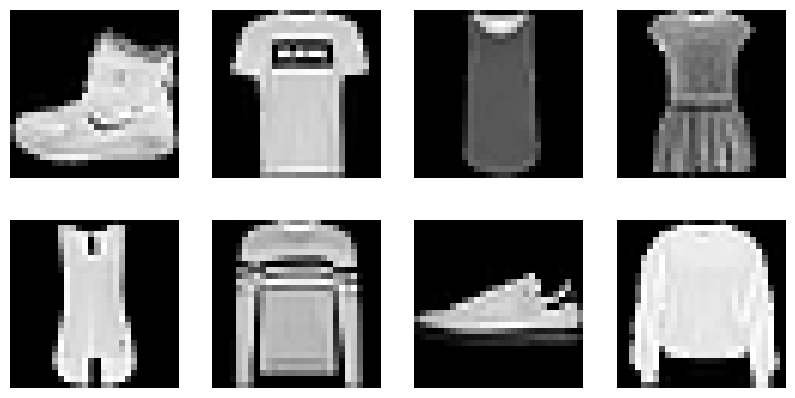

In [4]:
plt.figure(figsize=(10,5))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

### Build the Generator

In [5]:
latend_dim = 100

generator = keras.Sequential([
    layers.Dense(7*7*128, input_dim=latend_dim),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Reshape((7,7,128)),

    layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        1, kernel_size=4, strides=2, padding='same', activation='sigmoid'
    )
])

generator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 6272)              633472    
                                                                 
 batch_normalization (BatchN  (None, 6272)             25088     
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 6272)              0         
                                                                 
 reshape (Reshape)           (None, 7, 7, 128)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 14, 14, 64)       131136    
 nspose)                                                         
                                                                 
 batch_normalization_1 (Batc  (None, 14, 14, 64)       2

In [6]:
noise = tf.random.normal([1,latend_dim])

In [7]:
generated_image = generator(noise)

print(generated_image.shape)

(1, 28, 28, 1)


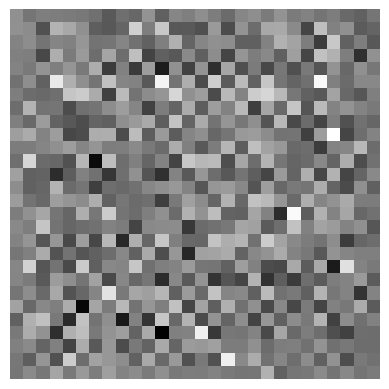

In [8]:
plt.imshow(generated_image[0,:,:,0], cmap='gray')
plt.axis('off')
plt.show()

### Build the Discriminator

In [15]:
discriminator = keras.Sequential([
    
    layers.Input(shape=(28,28,1)),
    #28x28x1 -> 14x14x64
    layers.Conv2D(64,kernel_size=4,strides=2,padding='same'),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    #14x14x64 -> 7x7x128
    layers.Conv2D(128,kernel_size=4,strides=2,padding='same'),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')

])
discriminator.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 14, 14, 64)        1088      
                                                                 
 leaky_re_lu_12 (LeakyReLU)  (None, 14, 14, 64)        0         
                                                                 
 dropout_10 (Dropout)        (None, 14, 14, 64)        0         
                                                                 
 conv2d_9 (Conv2D)           (None, 7, 7, 128)         131200    
                                                                 
 leaky_re_lu_13 (LeakyReLU)  (None, 7, 7, 128)         0         
                                                                 
 dropout_11 (Dropout)        (None, 7, 7, 128)         0         
                                                                 
 flatten_5 (Flatten)         (None, 6272)             

In [16]:
decision = discriminator(generated_image)
print(decision)

tf.Tensor([[0.51311165]], shape=(1, 1), dtype=float32)


### Compile Discriminator

In [19]:
discriminator.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

### Combine generator and discriminator into the GAN

In [21]:
discriminator.trainable = False 

gan_input = keras.Input(shape=(latend_dim,))
fake_image = generator(gan_input)
gan_output = discriminator(fake_image)

gan = keras.Model(gan_input, gan_output)

gan.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [31]:
epochs = 20000
batch_size = 128 

for epoch in range(epochs):
    #Train Discriminator
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_images = X_train[idx]

    noise = np.random.normal(0,1, (batch_size,latend_dim))
    fake_images = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((batch_size,1)))

    #Train Generator 
    noise = np.random.normal(0,1, (batch_size,latend_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 1000 == 0:
        print(
            f"Epoch: {epoch} |",
            f"D_Loss: {d_loss_real[0]:.4f} |",
            f"G_Loss: {g_loss[0]:.4f} |"
        )



Epoch: 0 | D_Loss: 0.4776 | G_Loss: 0.9916 |
Epoch: 1000 | D_Loss: 0.6357 | G_Loss: 0.8806 |
Epoch: 2000 | D_Loss: 0.6523 | G_Loss: 0.9530 |
Epoch: 3000 | D_Loss: 0.6872 | G_Loss: 0.9330 |
Epoch: 4000 | D_Loss: 0.6631 | G_Loss: 0.8677 |
Epoch: 5000 | D_Loss: 0.6263 | G_Loss: 0.9542 |
Epoch: 6000 | D_Loss: 0.6306 | G_Loss: 0.7972 |
Epoch: 7000 | D_Loss: 0.6980 | G_Loss: 0.7619 |
Epoch: 8000 | D_Loss: 0.6369 | G_Loss: 0.9451 |
Epoch: 9000 | D_Loss: 0.6220 | G_Loss: 0.8137 |
Epoch: 10000 | D_Loss: 0.5990 | G_Loss: 0.8463 |
Epoch: 11000 | D_Loss: 0.6473 | G_Loss: 0.8148 |
Epoch: 12000 | D_Loss: 0.6747 | G_Loss: 0.7406 |
Epoch: 13000 | D_Loss: 0.6169 | G_Loss: 0.8403 |
Epoch: 14000 | D_Loss: 0.6543 | G_Loss: 0.8015 |
Epoch: 15000 | D_Loss: 0.6654 | G_Loss: 0.8096 |
Epoch: 16000 | D_Loss: 0.6391 | G_Loss: 0.8388 |
Epoch: 17000 | D_Loss: 0.6506 | G_Loss: 0.8364 |
Epoch: 18000 | D_Loss: 0.6662 | G_Loss: 0.8287 |
Epoch: 19000 | D_Loss: 0.6891 | G_Loss: 0.8385 |


#### Generate New Images

In [32]:
noise = np.random.normal(0,1, (10,latend_dim))
generated_images = generator.predict(noise, verbose=0)

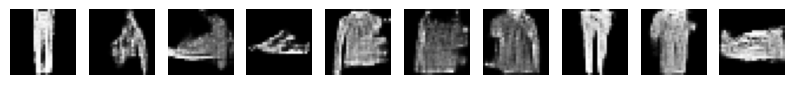

In [36]:
plt.figure(figsize=(10,8))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(generated_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()